In [1]:
import torch
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_path = "/scratch1/smaruj/orca_validation/orca_validation_fold0.tsv"
df = pd.read_csv(df_path, sep="\t")

In [4]:
def vector_to_symmetric_matrix(vec, N):
    matrix = torch.zeros((N, N), dtype=vec.dtype)
    triu_indices = torch.triu_indices(N, N)
    matrix[triu_indices[0], triu_indices[1]] = vec
    matrix = matrix + matrix.T - torch.diag(torch.diag(matrix))
    return matrix

In [5]:
output_dir = "/scratch1/smaruj/orca_validation/fold0_orca_preds"
N = 256
diagonal_offset = 2

/tmp/SLURM_1349767/ipykernel_2093030/1844763212.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vec = torch.load(file_path)


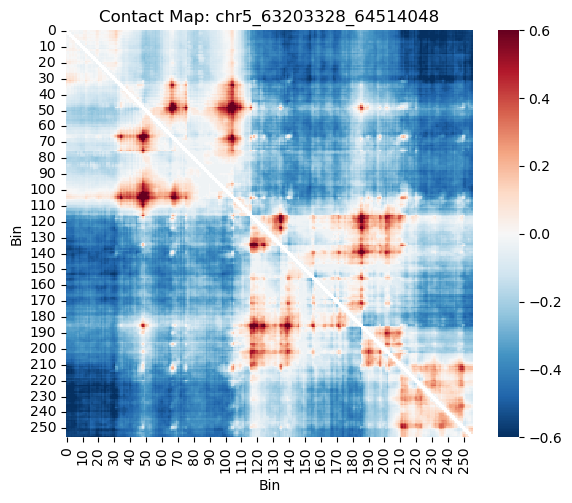

/tmp/SLURM_1349767/ipykernel_2093030/1844763212.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vec = torch.load(file_path)


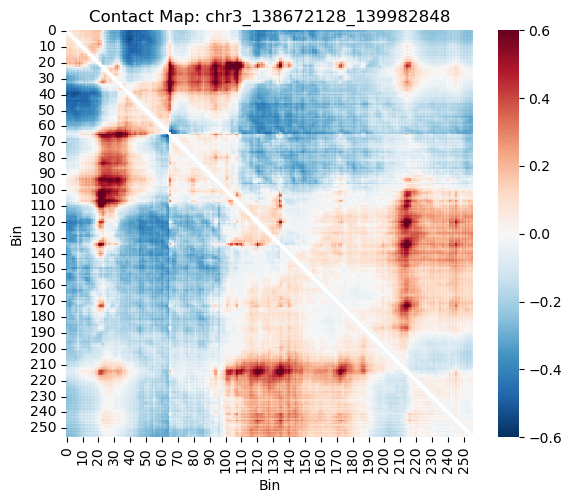

/tmp/SLURM_1349767/ipykernel_2093030/1844763212.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vec = torch.load(file_path)


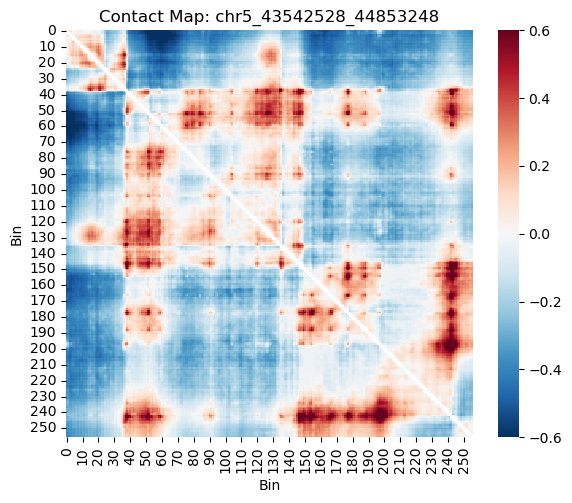

/tmp/SLURM_1349767/ipykernel_2093030/1844763212.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vec = torch.load(file_path)


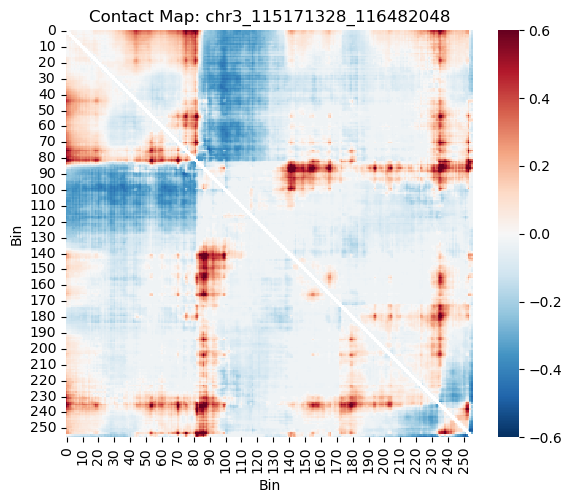

/tmp/SLURM_1349767/ipykernel_2093030/1844763212.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vec = torch.load(file_path)


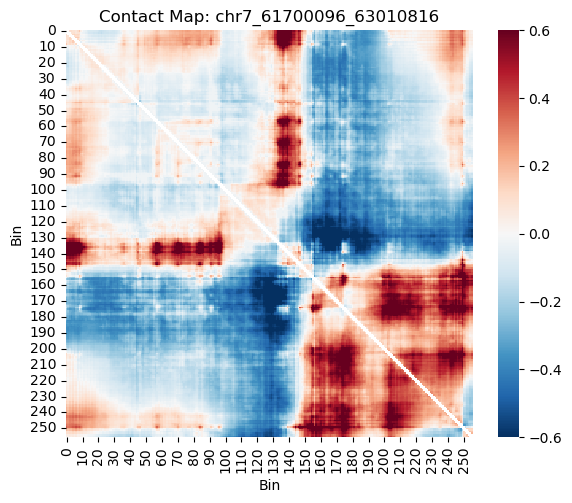

In [7]:
for idx, row in df[:5].iterrows():
    chrom = row["chrom"]
    start = int(row["start"])
    end = int(row["end"])
    
    filename = f"{chrom}_{start}_{end}_orca_pred.pt"
    file_path = f"{output_dir}/{filename}"
    
    vec = torch.load(file_path)
    matrix = vector_to_symmetric_matrix(vec, N).cpu().numpy()

    # Normalize matrix to median = 1 (optional)
    # matrix /= np.nanmedian(matrix)
    
    # 2. Remove diagonals
    for i in range(-1, 2):
        diag_indices = np.diag_indices_from(matrix)
        if i < 0:
            matrix[diag_indices[0][:i], diag_indices[1][-i:]] = np.nan
        elif i > 0:
            matrix[diag_indices[0][i:], diag_indices[1][:-i]] = np.nan
        else:
            matrix[diag_indices] = np.nan
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix, cmap="RdBu_r", square=True, cbar=True, vmin=-0.6, vmax=0.6)
    plt.title(f"Contact Map: {chrom}_{start}_{end}")
    plt.xlabel("Bin")
    plt.ylabel("Bin")
    plt.tight_layout()
    plt.show()
    